# Implement Recurrent Neural Network (RNN) / LSTM for time series data

## 1. Import Required Libraries
Import data manipulation, visualization, pre-processing, and deep learning libraries (TensorFlow/Keras).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

sns.set_style('whitegrid')

## 2. Load and Visualize Data
Load the `PJMW_hourly.csv` file, organize the Datetime index, and check the distribution.

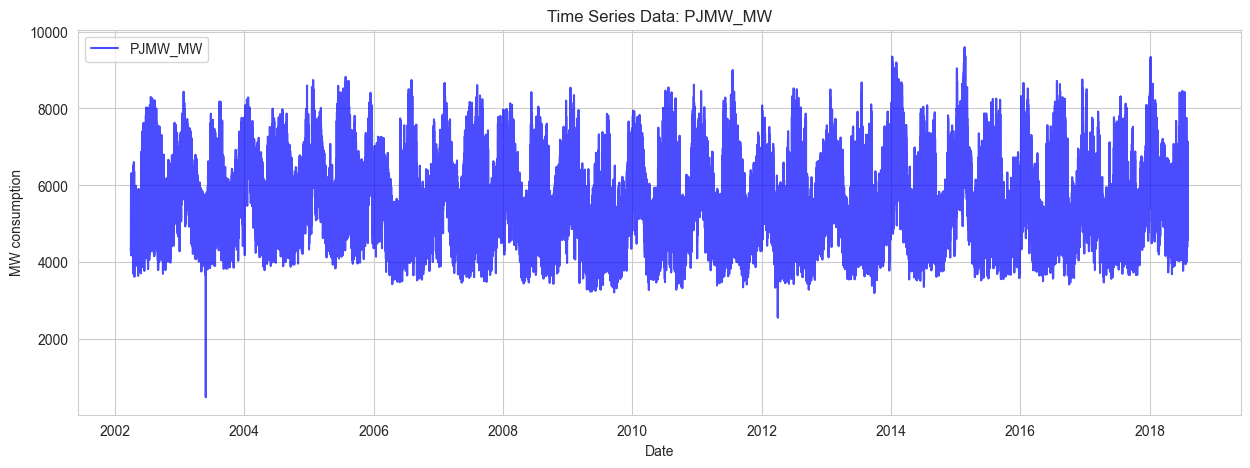

,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374.0
2002-04-01 02:00:00,4306.0
2002-04-01 03:00:00,4322.0
2002-04-01 04:00:00,4359.0
2002-04-01 05:00:00,4436.0


In [3]:
# Load Dataset
df = pd.read_csv('PJMW_hourly.csv')

# Handle Datetime index
if 'Datetime' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df.set_index('Datetime', inplace=True)
    df.sort_index(inplace=True)

# Select the target variable column (Assuming it's the remaining column PJMW_MW)
target_col = df.columns[0]

plt.figure(figsize=(15, 5))
plt.plot(df.index, df[target_col], label=target_col, color='blue', alpha=0.7)
plt.title(f'Time Series Data: {target_col}')
plt.xlabel('Date')
plt.ylabel('MW consumption')
plt.legend()
plt.show()

df.head()

## 3. Data Preprocessing
Extract the primary value as a numpy array, apply `MinMaxScaler` bound to (0, 1), handle proper train/test split, and generate shifted sequences (Windowing) for training the LSTM model properly.

In [4]:
# Extract raw numpy array
data = df[[target_col]].values

# Calculate split sizes (~80% training / 20% testing)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# Scaling the data to (0, 1) to help the LSTM converge reliably
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
# We ONLY use transform on testing data to prevent data leakage!
scaled_test = scaler.transform(test_data)

def create_sequences(dataset, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(dataset)):
        X.append(dataset[i-seq_length:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

# Creating windows spanning [seq_length] steps backward
seq_length = 60
X_train, y_train = create_sequences(scaled_train, seq_length)
X_test, y_test = create_sequences(scaled_test, seq_length)

# Reshape input to be exactly 3D: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (114504, 60, 1)
X_test shape: (28582, 60, 1)


## 4. Building the LSTM Model

We will build a Sequential Keras model containing LSTM layers and Dropout regularization to prevent overfitting.

In [5]:
# Build the LSTM model
model = Sequential()

# Layer 1
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer predicting a single value
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Training Phase
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_data=(X_test, y_test), 
    verbose=1
)

d:\VESIT\MLDL\MLDL_Experiments\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - loss: 0.0052 - val_loss: 9.6824e-04
Epoch 2/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - loss: 0.0014 - val_loss: 3.9811e-04
Epoch 3/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - loss: 6.3944e-04 - val_loss: 2.9546e-04
Epoch 4/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 47s 26ms/step - loss: 3.8133e-04 - val_loss: 1.4443e-04
Epoch 5/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 3.0147e-04 - val_loss: 1.1496e-04
Epoch 6/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 2.7958e-04 - val_loss: 1.2201e-04
Epoch 7/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 2.6386e-04 - val_loss: 1.1300e-04
Epoch 8/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 2.6067e-04 - val_loss: 1.4483e-04
Epoch 9/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 2.5069e-04 - val_loss: 1.6435e-04
Epoch 10/10
1790/1790 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 2.4211e-04 - val_loss: 1.6320e-04


## 5. Model Evaluation and Visualization

Compute the predictions back in the original unscaled form so that errors are quantifiable, and plot the actual vs predicted time series sequence.

894/894 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Root Mean Squared Error (RMSE): 116.34


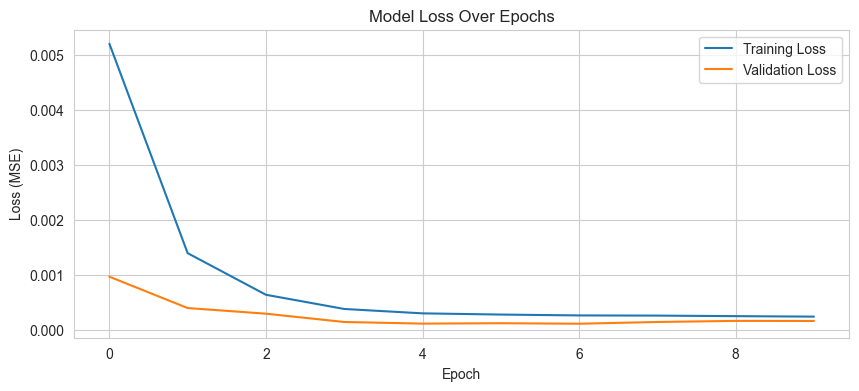

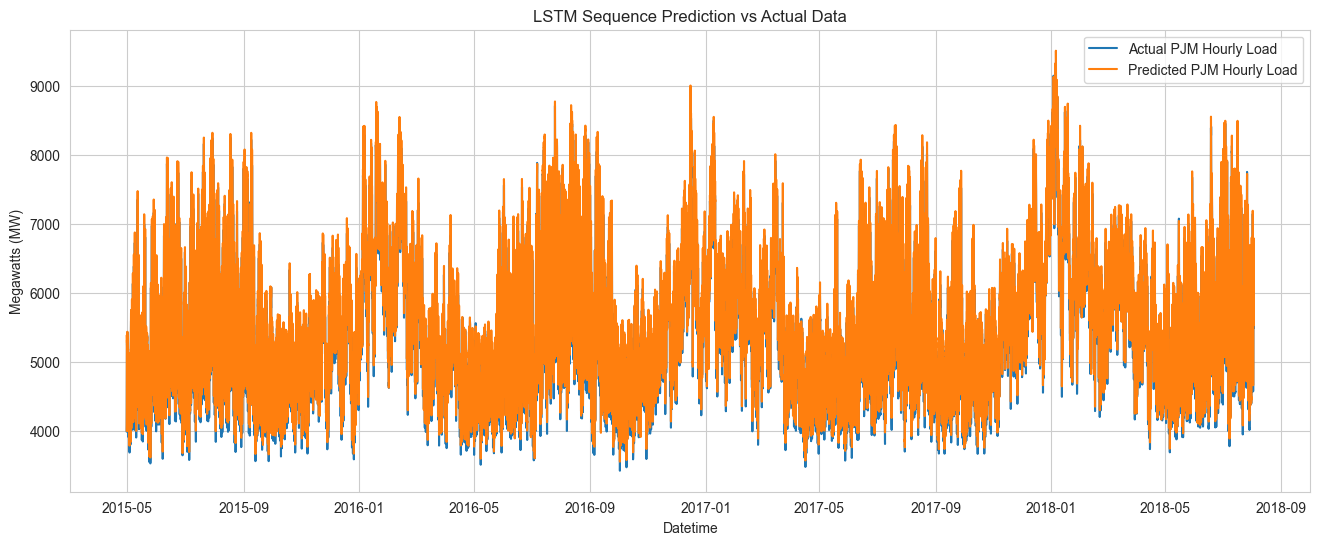

In [6]:
from sklearn.metrics import root_mean_squared_error

# Predict on the test data
predicted_scaled = model.predict(X_test)
# Inverse transform the normalized data to reconstruct actual value scales
predictions = scaler.inverse_transform(predicted_scaled)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = root_mean_squared_error(y_test_unscaled, predictions)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot Training loss vs Validation loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot the Actual vs Predicted values based on the unscaled real outputs
plt.figure(figsize=(16,6))
plt.plot(df.index[train_size+seq_length:], y_test_unscaled, color='tab:blue', label="Actual PJM Hourly Load")
plt.plot(df.index[train_size+seq_length:], predictions, color='tab:orange', label="Predicted PJM Hourly Load")
plt.title("LSTM Sequence Prediction vs Actual Data")
plt.xlabel("Datetime")
plt.ylabel("Megawatts (MW)")
plt.legend()
plt.show()